# 📓 Notebook Draft — Exploration & Prototypage
## Prédiction du Taux de Change EUR/TND
---
> ⚠️ **Note** : Ce notebook est un brouillon de travail (*draft*). Il documente les étapes d'exploration et les premières tentatives de modélisation, y compris les essais abandonnés (code commenté). Il ne représente pas la version finale du projet.
>
> La version finale se trouve dans **`notebooks/01_EDA.ipynb`** et **`notebooks/02_Modeling.ipynb`**.


In [ ]:
import pandas as pd
#pib_df = pd.read_excel('/content/PIB1.xlsx')
#display(pib_df.head())

---
## Étape 1 — Chargement & Fusion des Données
Fusion de tous les fichiers Excel (un par variable macroéconomique) en un seul DataFrame sur la colonne `Date`. Le PIB trimestriel a été préalablement transformé en données quotidiennes (voir notebook `Untitled9` dans le dossier `draft/`).


In [ ]:
# Select the row containing 'trimestre' information (index 1) and the 'PIB' row (index 30)
#pib_df = pib_df.iloc[[0, 29]]
#display(pib_df)

In [ ]:
# Extract the 'trimestre' row (index 1) and 'PIB' row (index 30) as Series, excluding the first descriptive column
#dates_row = pib_df.iloc[0, 1:]
#pib_row = pib_df.iloc[1, 1:]

# Create a new DataFrame with 'Date' and 'PIB' columns
#df_transformed = pd.DataFrame({
 #   'Date': dates_row.values,
  #  'PIB': pib_row.values
#})

# Convert 'PIB' column to numeric, coercing errors to NaN
#df_transformed['PIB'] = pd.to_numeric(df_transformed['PIB'], errors='coerce')

#display(df_transformed.head())

### Conversion des types et renommage
On vérifie que la colonne `Date` est bien au format `datetime64` et on renomme les colonnes `close` dupliquées après la fusion (`close_x` → EURTND, etc.).


In [ ]:
# Extract the year from the 'Date' column
#df_transformed['Year'] = df_transformed['Date'].str.extract(r'(\d{4})').astype(int)

# Filter the DataFrame for the years 2015 to 2025
#df_filtered = df_transformed[(df_transformed['Year'] >= 2015) & (df_transformed['Year'] <= 2025)].copy()

# Drop the temporary 'Year' column if not needed for further analysis
#df_filtered = df_filtered.drop(columns=['Year'])

#display(df_filtered.head())

In [ ]:
#display(df_filtered.tail())

---
## Étape 2 — Nettoyage : Gestion des Valeurs Manquantes
Pour une série temporelle, le **Forward Fill** (propagation de la dernière valeur connue) est la méthode la plus adaptée. Le Backward Fill comble les NaN éventuels en début de série.


In [ ]:
# Mapping trimestre -> month start
#quarter_map = {'I': '01','II': '04','III': '07','IV': '10'}
# Extract quarter and year from the 'Date' column
#df_filtered['Quarter'] = df_filtered['Date'].str.split().str[0]
#df_filtered['Year_str'] = df_filtered['Date'].str.extract(r'(\d{4})') # Using Year_str to avoid conflict with potential 'Year' col from df_transformed before filtering


---
## Étape 3 — Feature Engineering : Variables de Lag (première version)
Première tentative avec seulement **5 lags**. L'analyse d'autocorrélation montrera qu'il faut aller jusqu'à **30 lags** pour capturer toute la mémoire de la série.


In [ ]:
# Convert to actual datetime (first day of the quarter)
#df_filtered['Date'] = pd.to_datetime(df_filtered['Year_str'] + '-' + df_filtered['Quarter'].map(quarter_map) + '-01')
#display(df_filtered.tail())


---
## Étape 4 — Modélisation : Tentative 1 (sans lags, sans normalisation correcte)
> ⚠️ **Problème** : Cette version n'inclut pas les lags et le scaler est appliqué sur tout le dataset (data leakage). Résultats non fiables.


In [ ]:
# Set Date as index (this was already done in the previous step, so it's already the index)
# df_filtered.set_index('Date', inplace=True)

# Create daily index
# Ensure the index is a datetime index before finding min/max
#daily_index = pd.date_range(start=df_filtered.index.min(), end=df_filtered.index.max(), freq='D')
#daily_df = df_filtered.resample('D').ffill().reset_index()

#display(daily_df.head())

In [ ]:
#daily_df.to_excel('/content/PIB_daily.xlsx', index=False)

In [ ]:
import os

# List of Excel files to merge (excluding PIB1.xlsx)
excel_files = [
    '/content/taux_interet_quotidienne.xlsx',
    '/content/EURTND_close_prices.xlsx',
    '/content/final_balance_commerciale_daily.xlsx',
    '/content/Brent_close_prices.xlsx',
    '/content/USDEUR_close_prices.xlsx',
    '/content/final_inflation_daily.xlsx',

]
daily_df=pd.read_excel('/content/PIB_daily.xlsx')

# Initialize the merged DataFrame with daily_df (PIB data)
merged_df = daily_df.copy()

for file_path in excel_files:
    try:
        # Read each Excel file
        df_temp = pd.read_excel(file_path)

        # Standardize the date column name to 'Date' and convert to datetime
        # Assuming the date column might be named 'Date', 'date', or the first column
        if 'Date' in df_temp.columns:
            df_temp['Date'] = pd.to_datetime(df_temp['Date'])
        elif 'date' in df_temp.columns:
            df_temp['Date'] = pd.to_datetime(df_temp['date'])
            df_temp = df_temp.drop(columns=['date'])
        else:
            # If no 'Date' or 'date' column, assume the first column is the date and rename it
            df_temp.rename(columns={df_temp.columns[0]: 'Date'}, inplace=True)
            df_temp['Date'] = pd.to_datetime(df_temp['Date'])

        # Merge with the main DataFrame on 'Date'
        # Use an outer merge to keep all dates from both DataFrames
        merged_df = pd.merge(merged_df, df_temp, on='Date', how='outer')
        print(f"Successfully merged {os.path.basename(file_path)}")

    except Exception as e:
        print(f"Could not merge {os.path.basename(file_path)}: {e}")

# Sort by Date
merged_df = merged_df.sort_values(by='Date').reset_index(drop=True)

display(merged_df.head())


Successfully merged taux_interet_quotidienne.xlsx
Successfully merged EURTND_close_prices.xlsx
Successfully merged final_balance_commerciale_daily.xlsx
Successfully merged Brent_close_prices.xlsx
Successfully merged USDEUR_close_prices.xlsx
Successfully merged final_inflation_daily.xlsx


,Date,PIB,taux_interet,close_x,Balance commerciale,close_y,close,inflation
0,2015-01-01,22403.1,4.75,2.2457,-12002.561,NaN,1.209863,5.0
1,2015-01-02,22403.1,4.75,2.2457,-12002.561,22.020000,1.208941,5.0
2,2015-01-03,22403.1,4.75,NaN,-12002.561,NaN,NaN,5.0
3,2015-01-04,22403.1,4.75,NaN,-12002.561,NaN,NaN,5.0
4,2015-01-05,22403.1,4.75,2.2480,-12002.561,20.700001,1.194643,5.0


In [ ]:
# Rename columns for clarity
merged_df = merged_df.rename(columns={
    'close_x': 'EURTND',
    'close_y': 'BRENT',
    'close': 'USDEUR'
})

display(merged_df.head())

,Date,PIB,taux_interet,EURTND,Balance commerciale,BRENT,USDEUR,inflation
0,2015-01-01,22403.1,4.75,2.2457,-12002.561,NaN,1.209863,5.0
1,2015-01-02,22403.1,4.75,2.2457,-12002.561,22.020000,1.208941,5.0
2,2015-01-03,22403.1,4.75,NaN,-12002.561,NaN,NaN,5.0
3,2015-01-04,22403.1,4.75,NaN,-12002.561,NaN,NaN,5.0
4,2015-01-05,22403.1,4.75,2.2480,-12002.561,20.700001,1.194643,5.0


---
## Étape 5 — Matrice de Corrélation (EDA)
Visualisation des relations linéaires entre les variables. Cette analyse est approfondie dans `01_EDA.ipynb`.


In [ ]:
#merged_df.to_excel('/content/merged_data.xlsx', index=False)

In [ ]:
merged_df['Date'] = pd.to_datetime(merged_df['Date'])
merged_df.dtypes

,0
Date,datetime64[ns]
PIB,float64
taux_interet,float64
EURTND,float64
Balance commerciale,float64
BRENT,float64
USDEUR,float64
inflation,float64


---
## Étape 6 — Modélisation : Tentative 2 (avec lags 1-5, split chronologique)
Amélioration par rapport à la tentative précédente : ajout des lags et correction du split chronologique. Le scaler est maintenant fitté uniquement sur le train.


l’analyse exploratoire (EDA). Avant le training, visualiser la relation entre features → target (EURTND) est très important pour comprendre ton modèle.

In [ ]:
#merged_df['EURTND_diff'] = merged_df['EURTND'].diff()

In [ ]:
merged_df.fillna(method='ffill', inplace=True)
merged_df.fillna(method='bfill', inplace=True)  # si NaN au début

/tmp/ipykernel_5856/1621238148.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged_df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_5856/1621238148.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged_df.fillna(method='bfill', inplace=True)  # si NaN au début


In [ ]:
for lag in range(1, 6):
    merged_df[f'EURTND_lag_{lag}'] = merged_df['EURTND'].shift(lag)

In [ ]:
X = merged_df[['Balance commerciale', 'taux_interet', 'inflation', 'PIB', 'USDEUR', 'BRENT']]
y = merged_df['EURTND']  # ou 'EURTND_diff' si tu prends les différences

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

---
## Étape 7 — Feature Engineering Avancé (essai, non retenu)
Tentative de création de nouvelles features dérivées :
- `EURTND_return` : variation relative quotidienne du taux EUR/TND
- `brent_return` : variation relative du prix du Brent
- `inflation_rate_ratio` : ratio inflation/taux d'intérêt

> ❌ Ces features n'ont pas amélioré les performances et n'ont pas été retenues dans la version finale.


In [ ]:
train_size = int(len(merged_df) * 0.8)
X_train, X_test = X_scaled[:train_size], X_scaled[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 0.026705497879347617


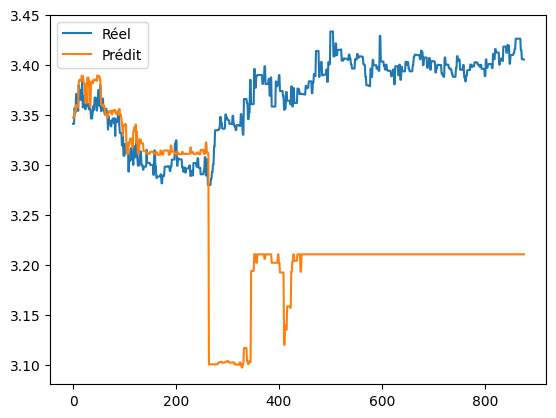

In [ ]:
import matplotlib.pyplot as plt

plt.plot(y_test.values, label='Réel')
plt.plot(y_pred, label='Prédit')
plt.legend()
plt.show()

In [ ]:
#import matplotlib.pyplot as plt
#plt.figure()
#plt.plot(merged_df['date'], merged_df['EURTND'], label='EURTND')
#plt.plot(merged_df['date'], merged_df['USDEUR'], label='USDEUR')
#plt.legend()
#plt.title("Evolution temporelle")
#plt.show()

In [ ]:
#for lag in range(1, 6):
#    merged_df[f'EURTND_lag_{lag}'] = merged_df['EURTND'].shift(lag)

In [ ]:
merged_df['Date'] = pd.to_datetime(merged_df['Date'])
merged_df.dtypes

,0
Date,datetime64[ns]
PIB,float64
taux_interet,float64
EURTND,float64
Balance commerciale,float64
BRENT,float64
USDEUR,float64
inflation,float64
EURTND_lag_1,float64
EURTND_lag_2,float64


In [ ]:
X = merged_df[['Balance commerciale', 'taux_interet', 'inflation', 'PIB', 'USDEUR', 'BRENT','EURTND_lag_1','EURTND_lag_2','EURTND_lag_3','EURTND_lag_4','EURTND_lag_5']]
y = merged_df['EURTND']  # ou 'EURTND_diff' si tu prends les différences

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # seulement transform !

In [ ]:
#train_size = int(len(merged_df) * 0.8)
#X_train, X_test = X_scaled[:train_size], X_scaled[train_size:]
#y_train, y_test = y[:train_size], y[train_size:]

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 0.00017904277842788842


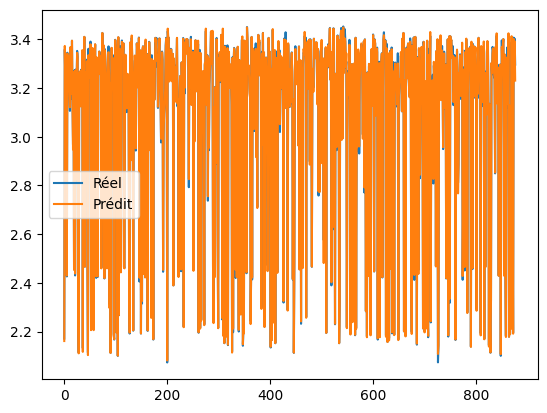

In [ ]:
import matplotlib.pyplot as plt

plt.plot(y_test.values, label='Réel')
plt.plot(y_pred, label='Prédit')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R²:", r2)

R²: 0.9988943348448633


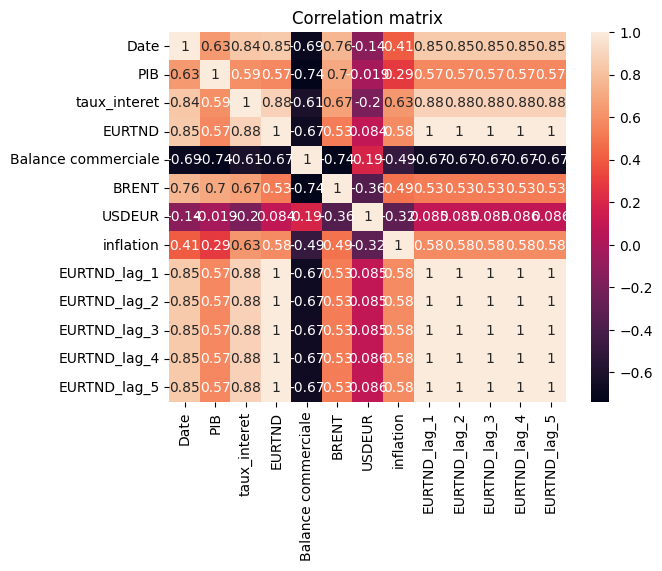

In [ ]:
import seaborn as sns

corr = merged_df.corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation matrix")
plt.show()

In [ ]:
merged_df['EURTND_lag1'] = merged_df['EURTND'].shift(1)
merged_df['EURTND_lag2'] = merged_df['EURTND'].shift(2)

In [ ]:
X = merged_df[['Balance commerciale', 'taux_interet','PIB', 'inflation', 'USDEUR', 'BRENT','EURTND_lag_1','EURTND_lag_2','EURTND_lag_3','EURTND_lag_4','EURTND_lag_5']]
y = merged_df['EURTND']  # ou 'EURTND_diff' si tu prends les différences

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
train_size = int(len(merged_df) * 0.8)
X_train, X_test = X_scaled[:train_size], X_scaled[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 0.0004939002161889541


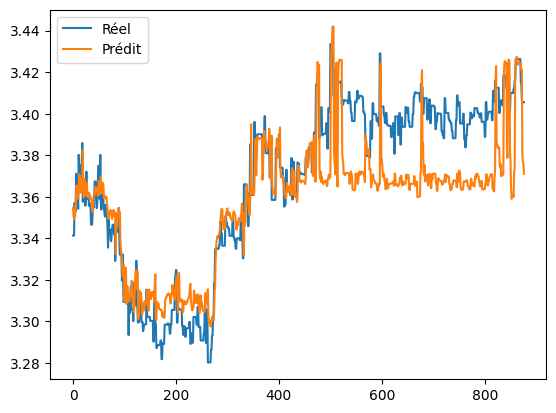

In [ ]:
import matplotlib.pyplot as plt

plt.plot(y_test.values, label='Réel')
plt.plot(y_pred, label='Prédit')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R²:", r2)

R²: 0.7038700989750517


In [ ]:
merged_df['EURTND_return'] = merged_df['EURTND'].pct_change()
merged_df['brent_return'] = merged_df['BRENT'].pct_change()

In [ ]:
merged_df['inflation_rate_ratio'] = merged_df['inflation'] / merged_df['taux_interet']

In [ ]:
X = merged_df[['Balance commerciale', 'taux_interet', 'inflation', 'PIB', 'USDEUR', 'brent_return','EURTND_lag_1','EURTND_lag_2','EURTND_lag_3','EURTND_lag_4','EURTND_lag_5','inflation_rate_ratio']]
y = merged_df['EURTND_return']  # ou 'EURTND_diff' si tu prends les différences

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
train_size = int(len(merged_df) * 0.8)
X_train, X_test = X_scaled[:train_size], X_scaled[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [ ]:
merged_df.fillna(method='ffill', inplace=True)
merged_df.fillna(method='bfill', inplace=True)

/tmp/ipykernel_5856/2674493779.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged_df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_5856/2674493779.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged_df.fillna(method='bfill', inplace=True)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 8.171388537560781e-06


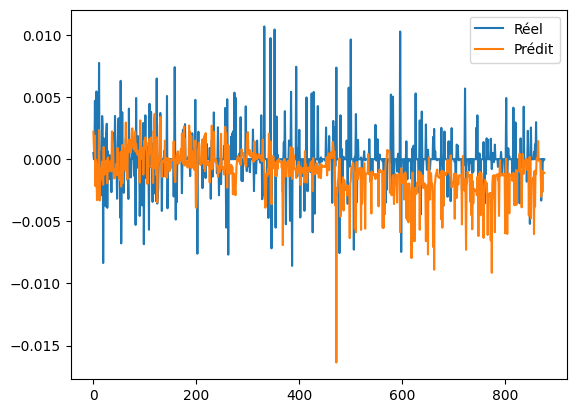

In [ ]:
import matplotlib.pyplot as plt

plt.plot(y_test.values, label='Réel')
plt.plot(y_pred, label='Prédit')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R²:", r2)

R²: -1.0141426108886842


---
## Conclusions du Draft
Ce notebook a permis d'identifier les enseignements suivants appliqués dans la version finale :

| Observation | Action dans la version finale |
|---|---|
| Split aléatoire → data leakage | ✅ Split chronologique (80/20) |
| 5 lags insuffisants | ✅ 30 lags après analyse autocorrélation |
| Scaler sur tout le dataset | ✅ fit sur train uniquement |
| Features dérivées (returns, ratios) | ❌ Non retenues (dégradent les résultats) |
| Un seul modèle testé | ✅ Deux modèles comparés (XGBoost + RandomForest) |
